# Phase 4: Model Evaluation & Explainability

## Objective

Evaluate the forecasting model and explain its predictions using SHAP values.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pickle

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import shap

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [4]:
import importlib
import src.utils.utils as utils

importlib.reload(utils)

<module 'src.utils.utils' from '/Users/linhnguyennhat/Downloads/sales-forecasting-by-sku/notebooks/../src/utils/utils.py'>

In [5]:
from src.utils.utils import (
    load_model,
    plot_sku_forecast,
    weighted_absolute_percentage_error
)

In [6]:
with open("../models/sales_forecast_model.pkl", "rb") as f:
    model = pickle.load(f)

data_feature = pd.read_csv(
    "../data/processed/data_engineered.csv",
    parse_dates=["shipped_date"]
)

data_feature.head()

,shipped_date,sku,channel,qty,revenue,COGS,MOQ_orders,month,day,dayofweek,...,mean_qty_sku_dow,mean_qty_sku_month,qty_log,lag1,lag7,lag30,rolling_mean_7,rolling_mean_30,rolling_std_7,rolling_std_30
0,2021-01-03,017SAD,ADS,75,3358.95,1660.05,1425,1,3,6,...,0.0,0.0,4.330733,NaN,NaN,NaN,75.0,75.0,NaN,NaN
1,2021-01-15,017SAD,ADS,75,3358.95,1660.05,1425,1,15,4,...,75.0,75.0,4.330733,75.0,NaN,NaN,75.0,75.0,0.0,0.0
2,2021-02-16,017SAD,ADS,75,3358.95,1660.05,1425,2,16,1,...,75.0,75.0,4.330733,75.0,NaN,NaN,75.0,75.0,0.0,0.0
3,2021-02-16,017SAD,LAL,75,2310.00,2009.70,1425,2,16,1,...,75.0,75.0,4.330733,75.0,NaN,NaN,75.0,75.0,0.0,0.0
4,2021-02-26,017SAD,ADS,75,3358.95,1660.05,1425,2,26,4,...,75.0,75.0,4.330733,75.0,NaN,NaN,75.0,75.0,0.0,0.0


In [28]:
data_model = data_feature.sort_values("shipped_date")

split_idx = int(len(data_model) * 0.8)

train = data_model.iloc[:split_idx]
test = data_model.iloc[split_idx:]

X_train = train.drop(columns=["qty_log"])
y_train = train["qty_log"]

X_test = test.drop(columns=["qty_log"])
y_test = test["qty_log"]

drop_cols = [
    "qty",
    "shipped_date",
    "sku",
    "revenue",
    "COGS",
    "channel",
    "MOQ_orders"
]

X_train = X_train.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

In [39]:
pred_log = model.predict(X_test)

prediction = np.expm1(pred_log)

actual = np.expm1(y_test)

In [40]:
test = test.copy()

test["prediction"] = prediction

test.head()

,shipped_date,sku,channel,qty,revenue,COGS,MOQ_orders,month,day,dayofweek,...,mean_qty_sku_month,qty_log,lag1,lag7,lag30,rolling_mean_7,rolling_mean_30,rolling_std_7,rolling_std_30,prediction
26536,2021-10-30,JTXMAP,ADS,16,1893.47,1500.80,41920,10,30,5,...,144.000000,2.833213,128.0,144.0,16.0,121.142857,120.533333,124.915209,86.391145,37.328288
1687,2021-10-30,1JKADT,FBA,98,1507.83,1341.97,978040,10,30,5,...,740.266667,4.595120,490.0,490.0,1666.0,616.000000,688.000000,661.564812,590.128215,140.041865
17401,2021-10-30,C3KMT3,FBM,60,3191.16,2584.84,53784,10,30,5,...,42.857143,4.110874,84.0,48.0,168.0,39.428571,69.200000,26.576036,49.294610,30.451884
15270,2021-10-30,A9WS0A,AWH,711,13624.81,12840.66,389154,10,30,5,...,342.333333,6.568078,79.0,79.0,711.0,338.571429,363.400000,226.746450,240.694197,247.440388
37936,2021-10-30,SVXKJD,AWH,54,3673.40,3332.45,13572,10,30,5,...,47.076923,4.007333,18.0,18.0,18.0,59.142857,42.000000,26.928477,23.317893,57.047833


In [12]:
mae = mean_absolute_error(actual, prediction)

rmse = np.sqrt(
    mean_squared_error(actual, prediction)
)

r2 = r2_score(actual, prediction)

wape = weighted_absolute_percentage_error(
    actual,
    prediction
)

In [13]:
print("=" * 50)

print("Final LightGBM Performance")

print("=" * 50)

print(f"MAE  : {mae:.2f}")

print(f"RMSE : {rmse:.2f}")

print(f"R²   : {r2:.4f}")

print(f"WAPE : {wape:.2f}%")

Final LightGBM Performance
MAE  : 111.80
RMSE : 216.35
R²   : 0.5780
WAPE : 48.17%


## Visualize Forecast Results

In [14]:
df_prediction = test[
    [
        "shipped_date",
        "sku",
        "qty",
        "month",
        "quarter",
        "prediction"
    ]
].copy()

df_prediction.head()

,shipped_date,sku,qty,month,quarter,prediction
26536,2021-10-30,JTXMAP,16,10,4,37.328288
1687,2021-10-30,1JKADT,98,10,4,140.041865
17401,2021-10-30,C3KMT3,60,10,4,30.451884
15270,2021-10-30,A9WS0A,711,10,4,247.440388
37936,2021-10-30,SVXKJD,54,10,4,57.047833


In [16]:
sku_list = (
    df_prediction["sku"]
    .drop_duplicates()
    .sample(5, random_state=42)
    .tolist()
)

sku_list

['M8BHRW', 'ZMP58F', 'C5GM9N', 'W21N', 'JTXRZU']

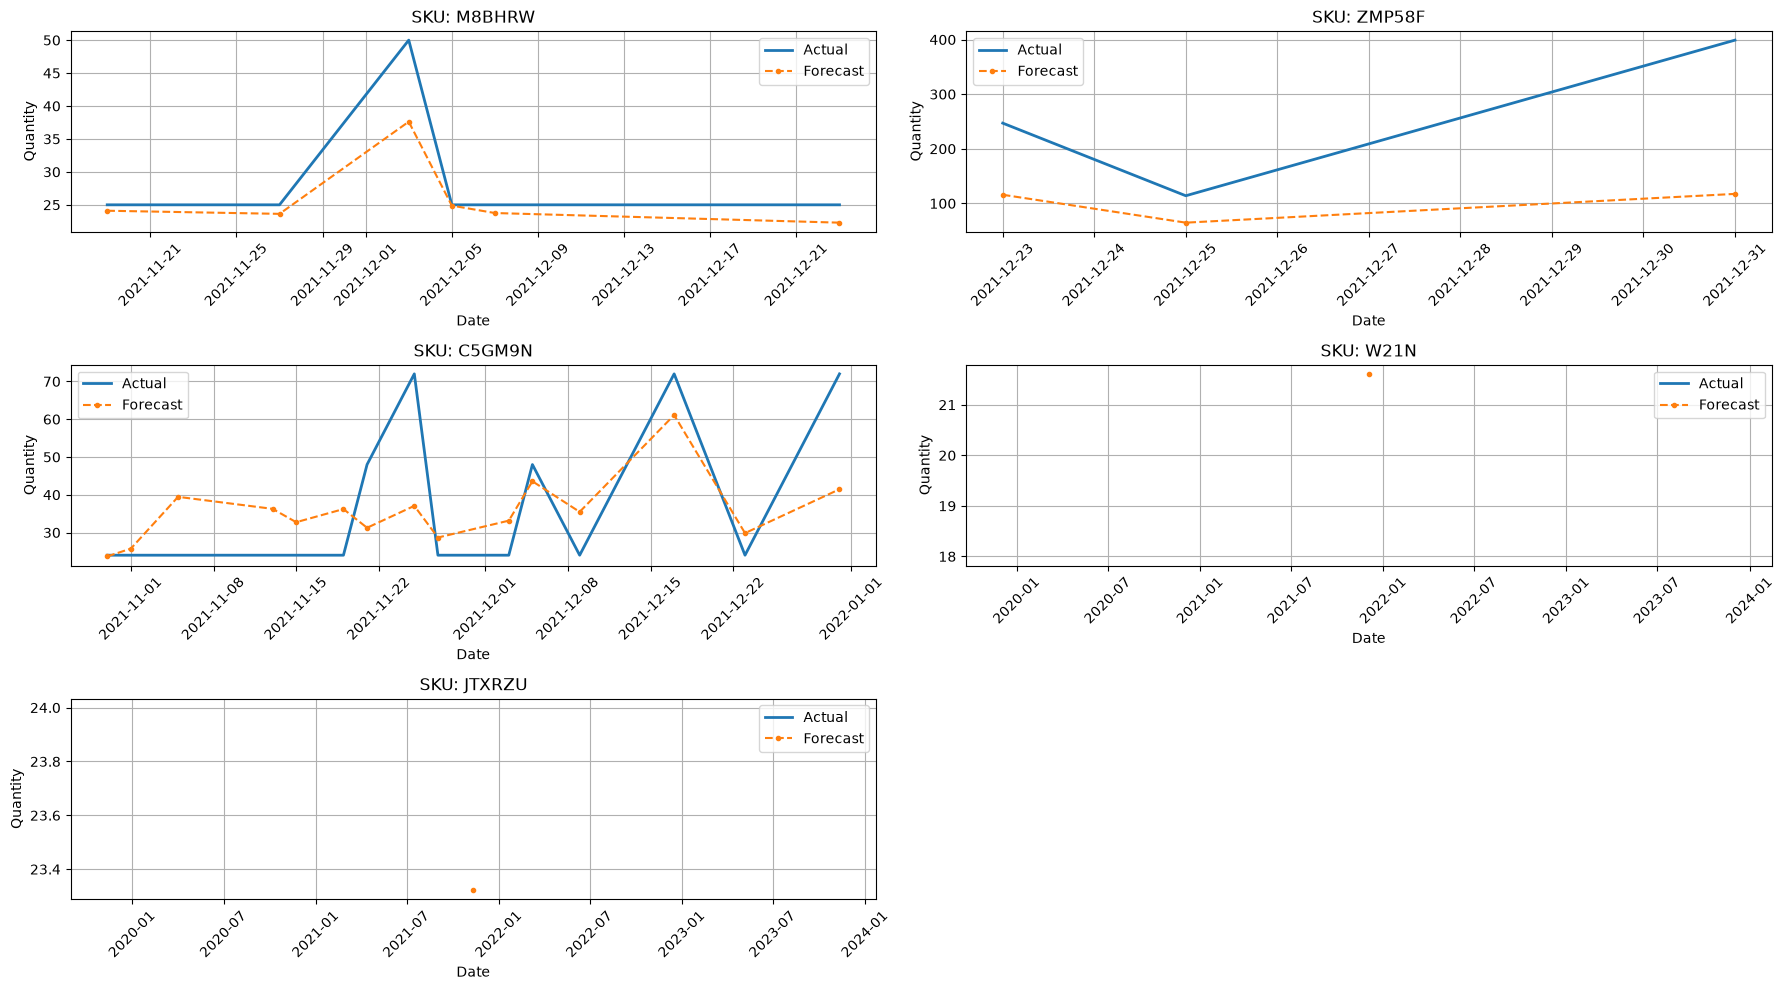

In [17]:
plot_sku_forecast(
    data=df_prediction,
    sku_list=sku_list,
    n_cols=2,
    figsize=(18,10)
)

### SHAP Global Feature Importance

In [30]:
X_train_sample = X_train.sample(
    min(500, len(X_train)),
    random_state=42
)

X_test_sample = X_test.sample(
    min(500, len(X_test)),
    random_state=42
)

X_sample = pd.concat([
    X_train_sample,
    X_test_sample
])

In [31]:
explainer = shap.TreeExplainer(model)

In [32]:
shap_values = explainer.shap_values(X_sample)

In [34]:
feature_importance = pd.DataFrame({
    "Feature": X_sample.columns,
    "Importance": np.abs(shap_values).mean(axis=0)
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
14,rolling_mean_7,0.813789
15,rolling_mean_30,0.171057
10,mean_qty_sku_month,0.097662
16,rolling_std_7,0.088551
11,lag1,0.061987
2,dayofweek,0.036789
9,mean_qty_sku_dow,0.023592
3,weekofyear,0.021897
1,day,0.017007
12,lag7,0.013840


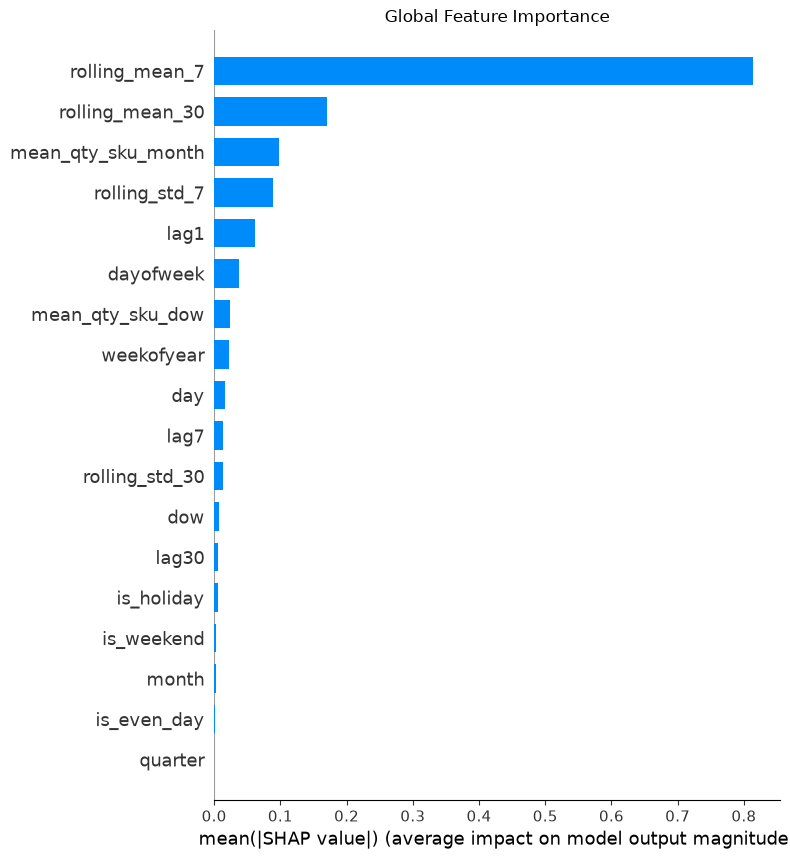

In [35]:
plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar",
    show=False
)

plt.title("Global Feature Importance")

plt.tight_layout()

plt.show()

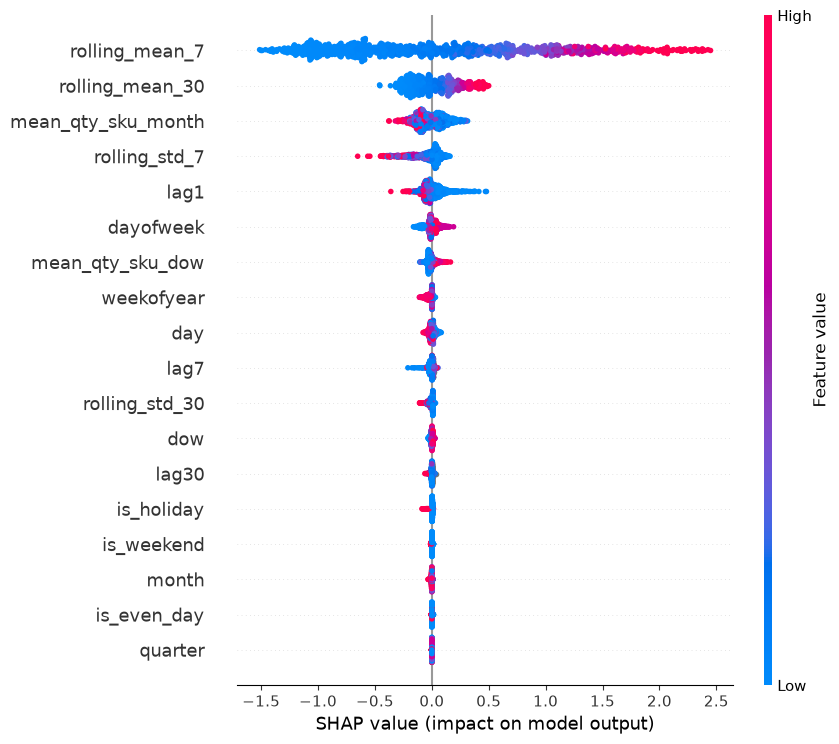

In [36]:
shap.plots.beeswarm(
    explainer(X_sample),
    max_display=20
)

### Key Findings

The model is mainly driven by historical sales information.

The most influential features include:

- lag30
- rolling_mean_7
- lag1
- lag7

This indicates that previous sales behaviour is the strongest predictor of future demand.

### SHAP Local Explanation

In [41]:
sample_indices = X_test.sample(
    3,
    random_state=2025
).index

SKU: YJZM4C
Date: 2021-12-27
Actual: 19.00
Prediction: 26.96


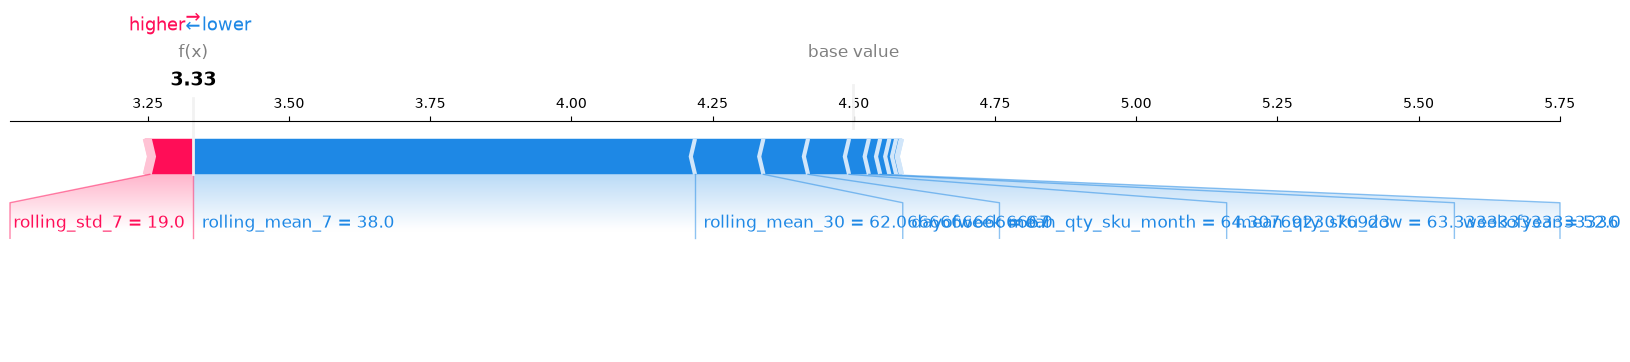

SKU: 4KCFJM
Date: 2021-12-23
Actual: 57.00
Prediction: 32.52


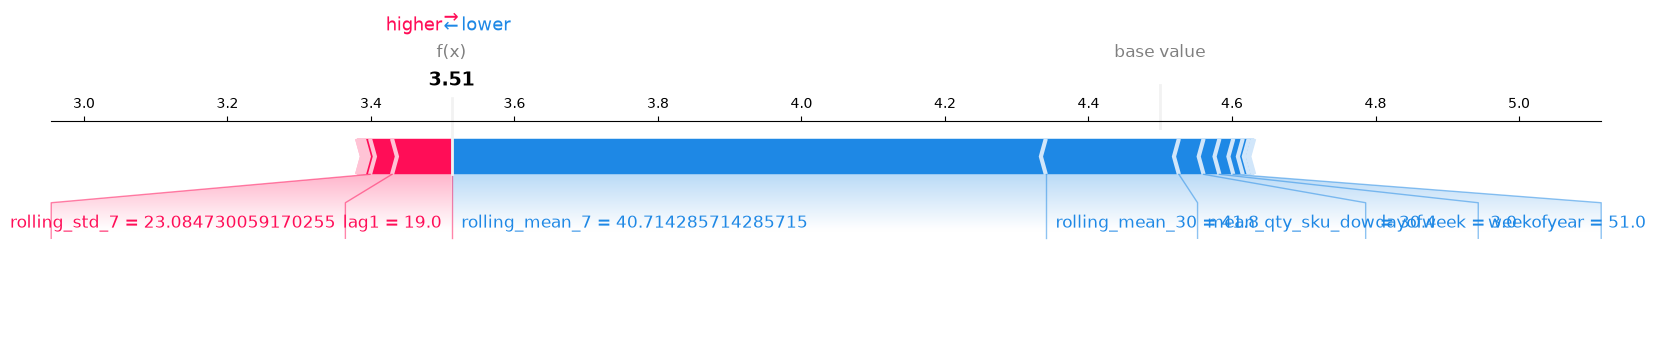

SKU: RHC5K2
Date: 2021-12-11
Actual: 25.00
Prediction: 23.71


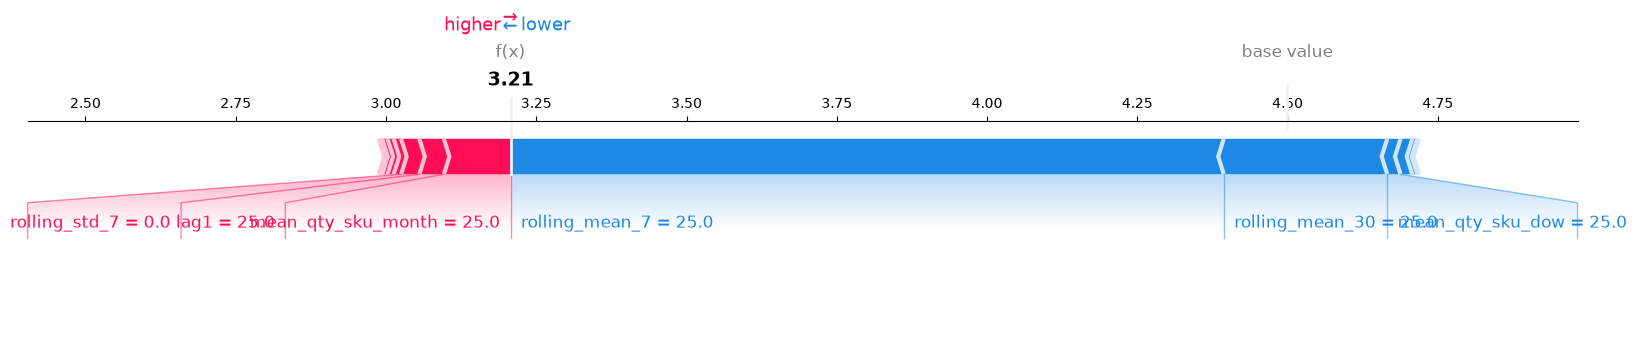

In [42]:
for idx in sample_indices:

    sample = X_test.loc[idx:idx]

    sample_shap = explainer.shap_values(sample)[0]

    sample_info = test.loc[test.index == idx]

    if len(sample_info) == 0:
        continue

    date = pd.to_datetime(
        sample_info["shipped_date"].iloc[0]
    )

    sku = sample_info["sku"].iloc[0]

    actual = sample_info["qty"].iloc[0]

    predicted = sample_info["prediction"].iloc[0]

    print("=" * 60)
    print(f"SKU: {sku}")
    print(f"Date: {date.date()}")
    print(f"Actual: {actual:.2f}")
    print(f"Prediction: {predicted:.2f}")

    shap.force_plot(
        explainer.expected_value,
        sample_shap,
        sample,
        matplotlib=True,
        show=True
    )